<a href="https://colab.research.google.com/github/RheaMimiCarillo/skillspire-ai-ml/blob/main/ADA_Lab_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Rhea Mimi Carillo

July 2026

# CHALLENGE

Find a way to achieve this, with codes we have discussed or codes from other resources. Let's build your ability to problem solve.

Github/StackOverflow/ChatGPT is allowed.

*Note: Review Lectures 3 & 4.*

GOALS: <br>
1. Use SuperStore Data.
2. Create an 'Age' Series from the data you have
3. Also create an 'AgeCat' Series that has the categories per generation.
Use the labeling age category attached below:
4. Extract at least 3 insights from the data you have.
5. Have at least 1 visualization

*hint:* <br>

For the age, let's say that our data is gathered on the last day of 2015, i.e., 31 December 2015.

***NOTE TO THE GRADER:** I am calculating doing my analysis based on the last day of 2025, i.e., 31 December 2025.*

**Labeling Age categories**

'Gen Z (13-28)': Ages from 13 to 28 (inclusive)
- born [1997, 2012]

'Gen Y (29-44)': Ages from 29 to 44 (inclusive)
- born [1981, 1996]

'Gen X (45-60)': Ages from 45 to 60 (inclusive)
- born [1965, 1980]

'Older (61-65)': Ages from 55 to 59 (inclusive)
- born [1964, 1960]

'Senior (66+)': Ages 66 and above
- born 1959 or earlier


**NOTE TO THE GRADER:** Since this assignment is so open-ended, I took the liberty to update the year ranges for **Gen Z, Gen Y, and Gen X** to align with the [Pew Research Center's generation category birth-year ranges.](https://www.pew.org/en/research-and-analysis/data-visualizations/2019/defining-our-six-generations)
- **'Older'** is calculated as **up to 5 years older** than Pew's oldest possible Gen X-er.
- **'Senior'** is calculated to be **6+ years older** than Pew's oldest possible Gen X-er. For the sake of consistency, I used the last day of the 2025 as the 'current' year.

In [ ]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# import data in google colab
from google.colab import files
uploaded = files.upload()

# expected file is 'SuperStore-Data.csv'

Saving SuperStore-Data.csv to SuperStore-Data.csv


In [ ]:
# assign csv file to a variable

store_data = 'SuperStore-Data.csv'

In [ ]:
# read csv into a dataframe
df = pd.read_csv(store_data)

df.head()

,Id,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Response,Complain
0,1826,1970,Graduation,D,84835.0,0,0,6/16/2014,0,189,...,111,189,218,1,4,4,6,1,1,0
1,1,1961,Graduation,S,57091.0,0,0,6/15/2014,0,464,...,7,0,37,1,7,3,7,5,1,0
2,10476,1958,Graduation,M,67267.0,0,1,5/13/2014,0,134,...,15,2,30,1,3,2,5,2,0,0
3,1386,1967,Graduation,T,32474.0,1,1,11/5/2014,0,10,...,0,0,0,1,1,0,2,7,0,0
4,5371,1989,Graduation,S,21474.0,1,0,8/4/2014,0,6,...,11,0,34,2,3,1,2,7,1,0


In [ ]:
# establish current year for age calculations
CURRENT_YEAR = 2025

In [ ]:
# check columns list
df.columns

Index(['Id', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Response', 'Complain', 'Age', 'AgeCat'],
      dtype='object')

In [ ]:
# 2. Create an ['Age'] Series
df['Age'] = CURRENT_YEAR - df['Year_Birth']

df.head()

,Id,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Response,Complain,Age,AgeCat
0,1826,1970,Graduation,D,84835.0,0,0,6/16/2014,0,189,...,218,1,4,4,6,1,1,0,55,Gen X (45-60)
1,1,1961,Graduation,S,57091.0,0,0,6/15/2014,0,464,...,37,1,7,3,7,5,1,0,64,Older (61-65)
2,10476,1958,Graduation,M,67267.0,0,1,5/13/2014,0,134,...,30,1,3,2,5,2,0,0,67,Senior (66+)
3,1386,1967,Graduation,T,32474.0,1,1,11/5/2014,0,10,...,0,1,1,0,2,7,0,0,58,Gen X (45-60)
4,5371,1989,Graduation,S,21474.0,1,0,8/4/2014,0,6,...,34,2,3,1,2,7,1,0,36,Gen Y (29-44)


In [ ]:
# 3. Create an ['AgeCat'] Seriesa

# The intervals
'''
'Gen Z (13-28)': Ages from 13 to 28 (inclusive)
- born [1997, 2012]

'Gen Y (29-44)': Ages from 29 to 44 (inclusive)
- born [1981, 1996]

'Gen X (45-60)': Ages from 45 to 60 (inclusive)
- born [1965, 1980]

'Older (61-65)': Ages from 55 to 59 (inclusive)
- born [1964, 1960]

'Senior (66+)': Ages 66 and above
- born 1959 or earlier
'''

# explicitly define custom bin intervals and labels for the ['AgeCat'] column
year_bins = [13, 28, 44, 60, 65, 150]
generation_labels = ['Gen Z (13-28)',
                     'Gen Y (29-44)',
                     'Gen X (45-60)',
                     'Older (61-65)',
                     'Senior (66+)']

# reminder for future Rhea:
# - count of bins must be exactly one more than the count of categories
# - bins are open on the left and closed on the right, i.e., intervals of (not-included, included]
# - can use pd.cut()'s ìnclude_lowest=True parameter explicitly change this behavior to [included, included]

In [85]:
# 3. (cont.) Map bins and labels to records
df['AgeCat'] = pd.cut(
    df['Age'],
    bins=year_bins,
    labels=generation_labels,
    include_lowest=True)

df.head()

df[['Year_Birth', 'Age', 'AgeCat']]

# Note to future Rhea:
#   - df['new_column_name'] = pd.cut(
#       df['the_existing_column'],
#       bins=the_interval_array,
#       labels=the_labels_array,
#       include_lowest=True) # include the minimum value

,Year_Birth,Age,AgeCat
0,1970,55,Gen X (45-60)
1,1961,64,Older (61-65)
2,1958,67,Senior (66+)
3,1967,58,Gen X (45-60)
4,1989,36,Gen Y (29-44)
...,...,...,...
2233,1976,49,Gen X (45-60)
2234,1977,48,Gen X (45-60)
2235,1976,49,Gen X (45-60)
2236,1978,47,Gen X (45-60)


In [101]:
# 4. (Simple) Insights from the data

# Mean & median income for each ['AgeCat']
mean_income_by_agecat = df.groupby('AgeCat', observed=False)['Income'].mean()
median_income_by_agecat = df.groupby('AgeCat', observed=False)['Income'].median()

income_table_by_agecat = pd.DataFrame({
    'Mean Income': mean_income_by_agecat,
    'Median Income': median_income_by_agecat
})

print("Mean and Median Income by Age Category:")
display(income_table_by_agecat)

# Mean # median income by education level
mean_income_by_education = df.groupby('Education', observed=False)['Income'].mean()
median_income_by_education = df.groupby('Education', observed=False)['Income'].median()

income_table_by_education = pd.DataFrame({
    'Mean Income': mean_income_by_education,
    'Median Income': median_income_by_education
})

print("Mean and Median Income by Education:")
display(income_table_by_education)


# Spending volume by 'AgeCat' per category (Wines, Fruits, Meat, Fish, Sweets, Gold Products)?
mean_spending_by_agecat = df.groupby('AgeCat', observed=False)[['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']].mean()

spending_table_by_agecat = pd.DataFrame({
    'Mean Wines': mean_spending_by_agecat['MntWines'],
    'Mean Fruits': mean_spending_by_agecat['MntFruits'],
    'Mean Meat': mean_spending_by_agecat['MntMeatProducts'],
    'Mean Fish': mean_spending_by_agecat['MntFishProducts'],
    'Mean Sweets': mean_spending_by_agecat['MntSweetProducts'],
    'Mean Gold': mean_spending_by_agecat['MntGoldProds']
})

print("Mean Spending by Age Category:")
display(spending_table_by_agecat)


# Note to future Rhea on the basics of insights:
# - df['ColumnName'].unique() is useful to get the shape of the data
# - for shopping data, it's useful to look at:
#   * Who they are (Demographic):
#     + 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome', 'Teenhome', 'Age', 'AgeCat
#         - 'T' in ['Marital_Status'] means 'Together'
#   * What they buy (Spending):
#     + 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds'
#   * How they shop (Channels):
#     + 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth'
#   * Additional (Context):
#     + Household dynamics, e.g., Gen Y with dependents on luxuries vs Gen Y w/o dependents spending on luxuries

Mean and Median Income by Age Category:


,Mean Income,Median Income
AgeCat,,
Gen Z (13-28),NaN,NaN
Gen Y (29-44),46562.105263,39104.0
Gen X (45-60),50579.169027,47808.0
Older (61-65),55556.539906,56067.0
Senior (66+),57993.882562,58936.5


Mean and Median Income by Education:


,Mean Income,Median Income
Education,,
Basic,20306.259259,20744.0
Bachelor,52720.373656,52028.5
2n Cycle,47633.190000,46805.0
Master,52917.534247,50943.0
PhD,56177.519833,55212.0


Mean Spending by Age Category:


,Mean Wines,Mean Fruits,Mean Meat,Mean Fish,Mean Sweets,Mean Gold
AgeCat,,,,,,
Gen Z (13-28),NaN,NaN,NaN,NaN,NaN,NaN
Gen Y (29-44),253.197403,28.618182,184.911688,40.080519,28.446753,43.098701
Gen X (45-60),268.721649,24.011246,147.863168,33.060918,25.200562,40.300843
Older (61-65),372.620370,28.194444,163.643519,38.851852,26.310185,48.560185
Senior (66+),378.033333,28.391228,192.210526,43.771930,29.984211,49.898246


According to the data, there were no Gen Z shoppers when these data were taken (31 Dec 2015).

The oldest Gen Z shoppers at the time would have been 18 years old at most (2015 minus 1997).

The actual shoppers in this dataset were born in 1996, making them solidly Gen Y.

In [87]:
# Actual youngest shopper age
print(f"Actual youngest shopper age: {df['Age'].min()}, (born: {df['Year_Birth'].max()}).")


Actual youngest shopper age: 29, (born: 1996).


In [100]:
# Proportion of spending for each product category by AgeCat
spending_columns = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
df['Total_Spending'] = df[spending_columns].sum(axis=1)

# Total spending per AgeCat
total_spending_by_agecat = df.groupby('AgeCat', observed=False)['Total_Spending'].sum()

# Total spending for each product category per AgeCat
spending_by_agecat = df.groupby('AgeCat', observed=False)[spending_columns].sum()

# Proportions
proportion_spending_by_agecat = spending_by_agecat.div(total_spending_by_agecat, axis=0) * 100

print("Proportion of Spending by Category for Each Age Category (%):")
display(proportion_spending_by_agecat.round(2))

Proportion of Spending by Category for Each Age Category (%):


,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds
AgeCat,,,,,,
Gen Z (13-28),NaN,NaN,NaN,NaN,NaN,NaN
Gen Y (29-44),43.78,4.95,31.97,6.93,4.92,7.45
Gen X (45-60),49.84,4.45,27.42,6.13,4.67,7.47
Older (61-65),54.94,4.16,24.13,5.73,3.88,7.16
Senior (66+),52.34,3.93,26.61,6.06,4.15,6.91


In [102]:
# Proportion of spending for each product category by Education Level

# Making the education levels more straightforward to understand before plotting
df['Education'] = df['Education'].replace('Graduation', 'Bachelor')

# Custom ordering for level
education_order = ['Basic', 'Bachelor', '2n Cycle', 'Master', 'PhD']

# Apply custom ordering of education levels ('Basic' first, ..., 'PhD')
df['Education'] = pd.Categorical(df['Education'], categories=education_order, ordered=True)

# Proportions by the Education levels
total_spending_by_education = df.groupby('Education', observed=False)['Total_Spending'].sum()
spending_by_education = df.groupby('Education', observed=False)[spending_columns].sum()
proportion_spending_by_education = spending_by_education.div(total_spending_by_education, axis=0) * 100

print("Proportion of Spending by Education Level (%):")
display(proportion_spending_by_education.round(2))

Proportion of Spending by Education Level (%):


,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds
Education,,,,,,
Basic,8.85,13.58,13.99,20.85,14.81,27.91
Bachelor,45.86,4.96,28.95,6.96,5.06,8.20
2n Cycle,39.91,5.83,28.45,9.56,6.90,9.34
Master,54.44,3.54,26.71,5.25,3.46,6.60
PhD,60.12,2.99,25.11,3.98,3.01,4.79


We can see that the proportion of spending by each product category *appears* to have greater variance across education levels than across age categories.

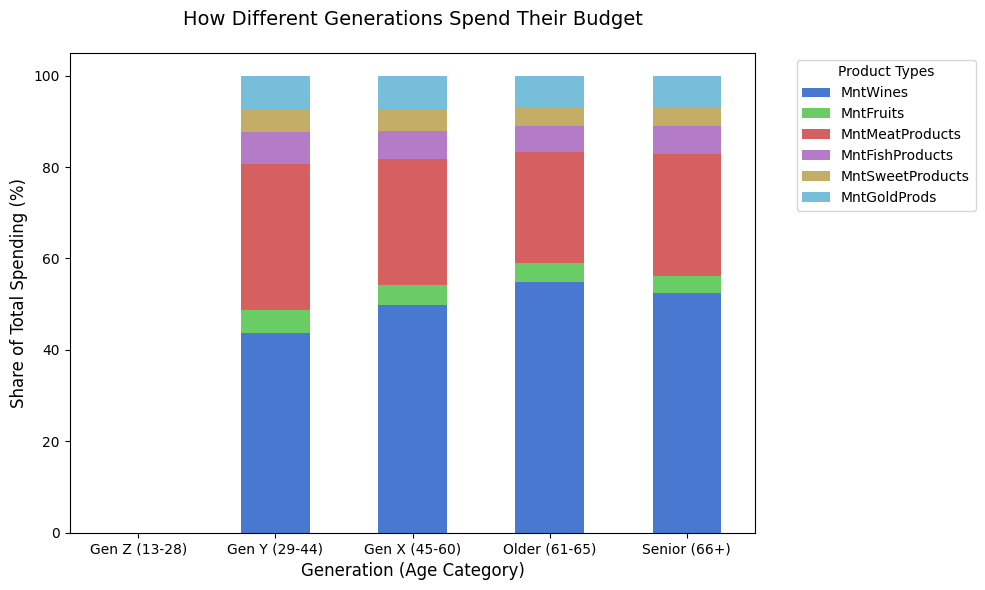

In [106]:
# 5. Data visualization

# Age Category
plt.style.use('seaborn-v0_8-muted')

ax = proportion_spending_by_agecat.plot(kind='bar',
                                        stacked=True,
                                        figsize=(10, 6))

plt.title('How Different Generations Spend Their Budget', fontsize=14, pad=20)
plt.xlabel('Generation (Age Category)', fontsize=12)
plt.ylabel('Share of Total Spending (%)', fontsize=12)
plt.legend(title='Product Types', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

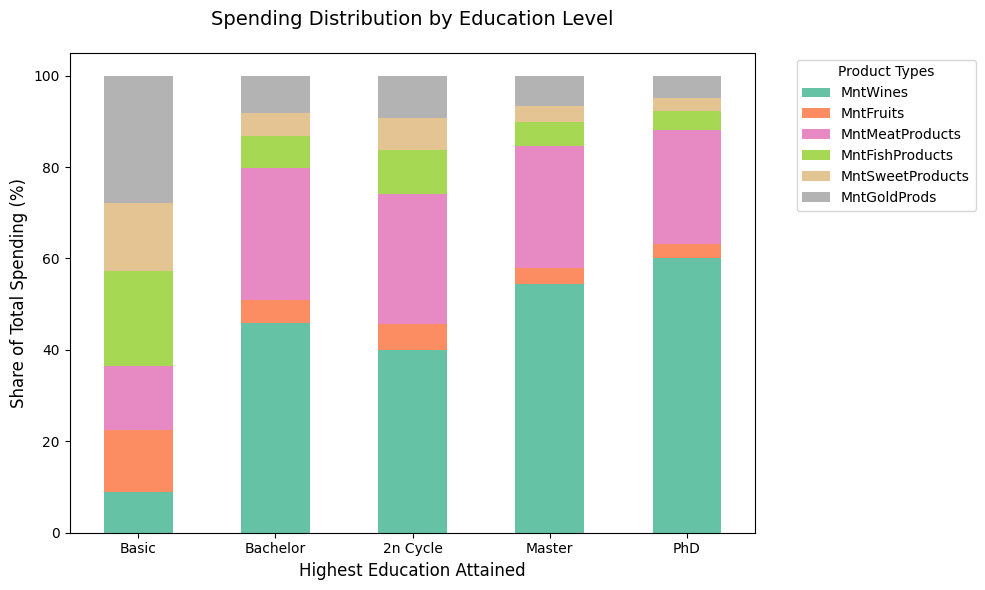

In [105]:
# Education Level
ax2 = proportion_spending_by_education.plot(kind='bar',
                                           stacked=True,
                                           figsize=(10, 6),
                                           colormap='Set2')

plt.title('Spending Distribution by Education Level', fontsize=14, pad=20)
plt.xlabel('Highest Education Attained', fontsize=12)
plt.ylabel('Share of Total Spending (%)', fontsize=12)
plt.legend(title='Product Types', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()